---
title: "Blog 04: Analysis of Pennsylvania Crash Data"
description: "placeholder"
author: "Daniel Park"
date: "2/25/2026"
categories:
  - car crashes
  - data stories
  - data visualization
---

### Legal firms citing crash data


> Roosevelt Boulevard, Philadelphia, Pennsylvania
> 
> While the other roads mentioned on this list are highways, Roosevelt Boulevard in Philadelphia is included because of its notoriety as one of the most dangerous thoroughfares in America. The boulevard consists of six 12-foot wide lanes in each direction, and drivers regularly exceed the posted 45 miles per hour and take the road’s dangerous curves far too fast. The boulevard also has two of the nation’s most dangerous intersections, where confused drivers frequently turn into the wrong three-lane stretch of traffic.

https://www.hg.org/legal-articles/5-of-the-most-dangerous-roads-in-the-u-s--32057

> Pennsylvania roads are dangerous, and with its large concentration of population, Philadelphia has the greatest number of crash-related deaths. In fact, according to PennDOT data on fatal car accidents, Philadelphia had more than a quarter of the road segments that were among the state’s most deadly from 2015-2017. During this period, Philly had 24 road segments with 155 total fatal collisions, leading to 167 deaths. This amounted to about a third of the segments with at least four deaths in the entire state.

https://www.wnwlaw.com/philly-four-pennsylvanias-ten-deadliest-roads/


* Study by law firm

https://www.dallashartman.com/blog/2019/01/deadly-roads-pa/

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

from shapely.geometry import Point

In [3]:
crash_data = pd.read_csv("data/PDOT_crash_data_2005_2024.csv", low_memory=False)
philly_zip = gpd.read_file("data/philadelphia_zip_boundaries.geojson")
data_dictionary = pd.read_csv('data/data_dictionary.csv')
div_gdf = gpd.read_file("data/Political_Divisions.geojson")
streets = gpd.read_file("data/Street_Centerline.geojson")

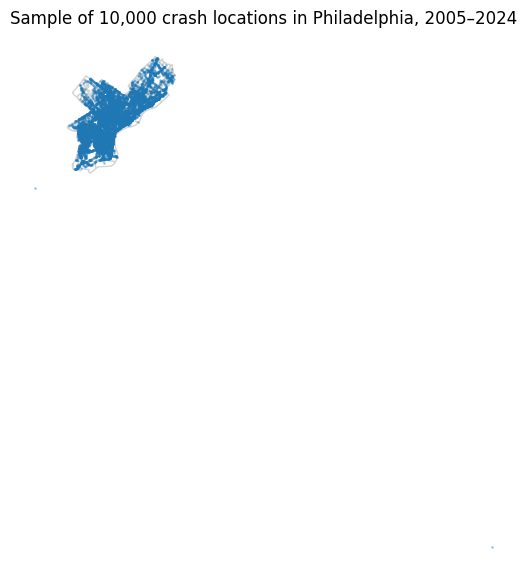

In [4]:
phil_filter = crash_data['COUNTY'] == 67

phil_crashes = crash_data[phil_filter].copy()

# remove rows without decimal coordinates
phil_crashes = phil_crashes.dropna(subset=['DEC_LATITUDE','DEC_LONGITUDE'])

phil_crashes.shape

geom = gpd.points_from_xy(phil_crashes['DEC_LONGITUDE'], phil_crashes['DEC_LATITUDE'])
phil_crashes_gdf = gpd.GeoDataFrame(phil_crashes, geometry=geom).set_crs('EPSG:4326')

philly_zip = gpd.read_file("data/philadelphia_zip_boundaries.geojson")

base = philly_zip.plot(color='white', edgecolor='lightgray', figsize=(7,7))
phil_crashes_gdf.sample(8000).plot(ax=base, markersize=1, alpha=0.3)
base.axis('off')
plt.title("Sample of 8,000 crash locations in Philadelphia, 2005–2024")
plt.show()

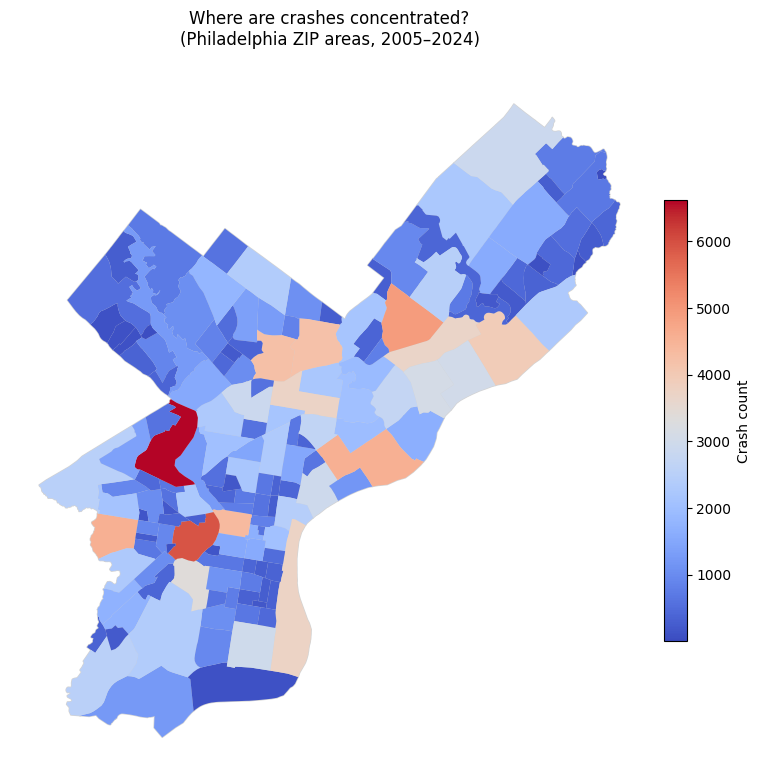

In [5]:
# spatial join: crashes -> zip polygons
zjoin = gpd.sjoin(philly_zip, phil_crashes_gdf, how='left', predicate='contains')

# dissolve by zip and count CRN values
zip_counts = zjoin.dissolve(by='listname', aggfunc={'CRN': 'count'})

# rename to a friendly column name
zip_counts = zip_counts.rename(columns={'CRN': 'crash_count'})

fig, ax = plt.subplots(figsize=(8,8))

philly_zip.plot(ax=ax, color='white', edgecolor='lightgray')

zip_counts.plot(
    ax=ax,
    column='crash_count',
    cmap='coolwarm',   # blue low -> red high
    legend=True,
    legend_kwds={'shrink': 0.6, 'label': 'Crash count', 'pad': 0.02}
)

ax.set_title("Where are crashes concentrated?\n(Philadelphia ZIP areas, 2005–2024)", pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

<Axes: xlabel='period'>

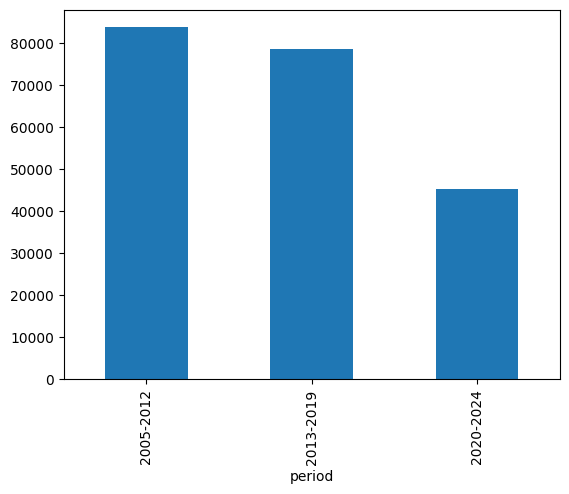

In [6]:
def period(year):
    if year <= 2012:
        return "2005-2012"
    elif year <= 2019:
        return "2013-2019"
    else:
        return "2020-2024"

phil_crashes_gdf['period'] = phil_crashes_gdf['CRASH_YEAR'].apply(period)

period_counts = phil_crashes_gdf.groupby('period').size()
period_counts.plot(kind='bar')

<Axes: xlabel='HOUR_OF_DAY'>

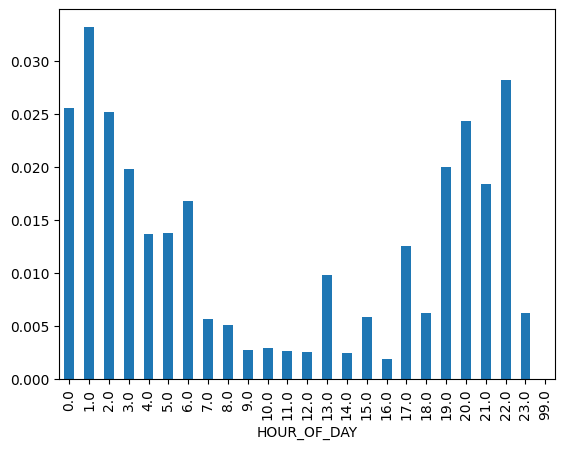

In [7]:
hour_severity = (
    phil_crashes
    .groupby('HOUR_OF_DAY')
    .agg(
        total_crashes=('CRN','count'),
        fatalities=('FATAL_COUNT','sum')
    )
)

hour_severity['fatal_rate'] = hour_severity['fatalities'] / hour_severity['total_crashes']

hour_severity['fatal_rate'].plot(kind='bar')

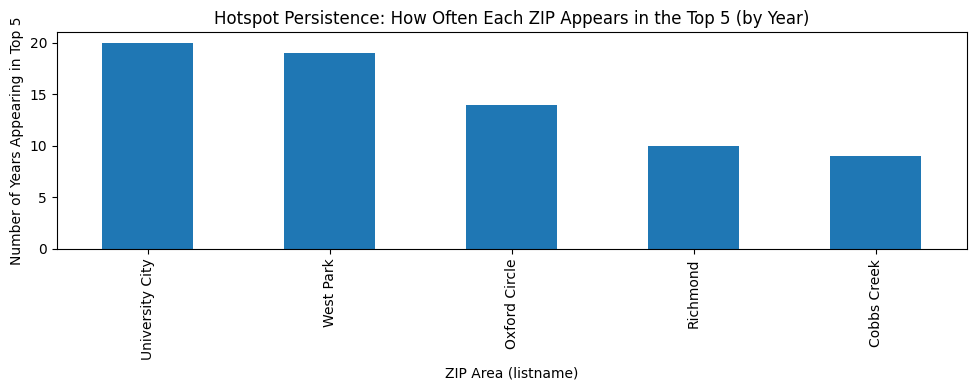

In [8]:
# count crashes per (year, zip)
top_each_year = (
    zjoin.groupby(['CRASH_YEAR', 'listname'])
    .size()
    .reset_index(name='count')
)

# sorting within each year so biggest counts come first
top_each_year = top_each_year.sort_values(['CRASH_YEAR', 'count'], ascending=[True, False])

# taking top 5 ZIP areas per year
top5_each_year = top_each_year.groupby('CRASH_YEAR').head(5)

# finding how many years each ZIP appears in the top 5
hotspot_frequency = top5_each_year['listname'].value_counts()

# finding the top 5 of the ZIPs above.
hotspot_frequency = hotspot_frequency.head(5)

# 5) plot
hotspot_frequency.plot(kind='bar', figsize=(10,4))
plt.title("Hotspot Persistence: How Often Each ZIP Appears in the Top 5 (by Year)")
plt.ylabel("Number of Years Appearing in Top 5")
plt.xlabel("ZIP Area (listname)")
plt.tight_layout()
plt.show()

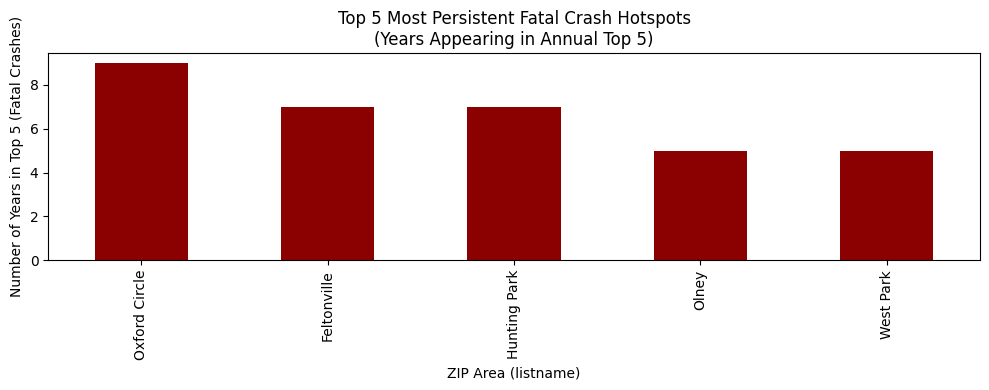

In [9]:
# 1) keep only crashes with at least 1 fatality
fatal_only = zjoin[zjoin['FATAL_COUNT'] > 0].copy()

# 2) count fatal crashes per (year, zip)
fatal_top_each_year = (
    fatal_only.groupby(['CRASH_YEAR', 'listname'])
    .size()
    .reset_index(name='fatal_crash_count')
)

# 3) sort within each year
fatal_top_each_year = fatal_top_each_year.sort_values(
    ['CRASH_YEAR', 'fatal_crash_count'],
    ascending=[True, False]
)

# 4) take top 5 ZIP areas per year
fatal_top5_each_year = fatal_top_each_year.groupby('CRASH_YEAR').head(5)

# 5) count how often each ZIP appears in yearly top 5
fatal_hotspot_frequency = fatal_top5_each_year['listname'].value_counts()

# 6) take top 5 most persistent fatal hotspots
top5_persistent_fatal = fatal_hotspot_frequency.head(5)

# 7) plot
top5_persistent_fatal.plot(kind='bar', figsize=(10,4), color='darkred')

plt.title("Top 5 Most Persistent Fatal Crash Hotspots\n(Years Appearing in Annual Top 5)")
plt.ylabel("Number of Years in Top 5 (Fatal Crashes)")
plt.xlabel("ZIP Area (listname)")
plt.tight_layout()
plt.show()

In [10]:
buffer_ft = 100

# The code section encapsulated with #s has been generated with the use of Generative AI.
###############################################
# 1) Filter + project streets once
streets = streets.to_crs(epsg=2272)

rb = streets[
    streets['st_name'].str.upper().str.contains('ROOSEVELT', na=False)
].copy()

# 2) Buffer to make a corridor polygon
rb_buf = gpd.GeoDataFrame(geometry=rb.buffer(buffer_ft), crs=streets.crs)

# 3) Filter + project crashes once
city_11_15 = phil_crashes_gdf.query("2011 <= CRASH_YEAR <= 2015").to_crs(epsg=2272)

# 4) Join + dedupe
joined = gpd.sjoin(city_11_15, rb_buf, predicate='within').drop_duplicates('CRN')
##############################################

# 5) Stats
city_fatal = city_11_15['FATAL_COUNT'].sum()
rb_fatal   = joined['FATAL_COUNT'].sum()

rb_share = rb_fatal / city_fatal if city_fatal else np.nan

rb_inj  = joined['TOT_INJ_COUNT'].sum()
rb_ped  = joined['PED_DEATH_COUNT'].sum()
rb_ped_share = rb_ped / rb_fatal if rb_fatal else np.nan

print("Crashes identified:", len(joined))
print("Fatalities:", int(rb_fatal))
print("Share of city fatalities:", f"{rb_share:.1%}")
print("Injuries:", int(rb_inj))
print("Pedestrian deaths:", int(rb_ped))
print("Pedestrian share of Roosevelt deaths:", f"{rb_ped_share:.1%}")

Crashes identified: 3606
Fatalities: 65
Share of city fatalities: 13.8%
Injuries: 4445
Pedestrian deaths: 22
Pedestrian share of Roosevelt deaths: 33.8%


In [13]:
# project entire crash dataset once
all_crashes = phil_crashes_gdf.to_crs(epsg=2272)

pre = all_crashes[(all_crashes['CRASH_YEAR'] >= 2011) & (all_crashes['CRASH_YEAR'] <= 2019)]
post = all_crashes[(all_crashes['CRASH_YEAR'] >= 2020) & (all_crashes['CRASH_YEAR'] <= 2024)]

pre_stats = roosevelt_stats(pre, rb_all_buf)
post_stats = roosevelt_stats(post, rb_all_buf)

print("Pre-2020 (2011–2019)")
print("Roosevelt fatalities:", pre_stats[0])
print("City fatalities:", pre_stats[1])
print("Share:", round(pre_stats[2],4), f"({pre_stats[2]:.1%})")

print("\nPost-2020 (2020–2024)")
print("Roosevelt fatalities:", post_stats[0])
print("City fatalities:", post_stats[1])
print("Share:", round(post_stats[2],4), f"({post_stats[2]:.1%})")

NameError: name 'roosevelt_stats' is not defined

In [14]:
years = sorted(all_crashes['CRASH_YEAR'].unique())

year_results = []

for y in years:
    subset = all_crashes[all_crashes['CRASH_YEAR'] == y]
    rb_fatal, city_fatal, share = roosevelt_stats(subset, rb_all_buf)
    year_results.append([y, rb_fatal, city_fatal, share])

import pandas as pd
year_df = pd.DataFrame(year_results, columns=['year','rb_fatal','city_fatal','share'])

year_df

plt.figure(figsize=(8,4))
plt.plot(year_df['year'], year_df['share'], marker='o')
plt.axvline(2020, linestyle='--', color='red', alpha=0.6)
plt.title("Roosevelt Blvd Share of City Fatalities Over Time")
plt.ylabel("Share of City Fatalities")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

NameError: name 'roosevelt_stats' is not defined

In [15]:
# 1) start from your existing joined dataframe j (already has road_name + road_geom)
j2 = j.dropna(subset=["road_name"]).copy()

# 2) ensure everything is in a feet-based CRS for distance (2272)
# (If j2 is already 2272, this does nothing harmful.)
j2 = j2.to_crs(epsg=2272)

# 3) convert road_geom (plain Series) -> GeoSeries so .distance works row-wise
road_geom_gs = gpd.GeoSeries(j2["road_geom"], index=j2.index, crs=j2.crs)

# 4) keep the closest road match per crash record (avoids double counting at intersections)
j2["dist"] = j2.geometry.distance(road_geom_gs)
j2 = j2.sort_values("dist").drop_duplicates(subset=["CRN"])

# 5) fatalities per road
fatal_by_road = j2.groupby("road_name")["FATAL_COUNT"].sum()

# 6) road length per road (miles)
streets_2272 = streets.to_crs(epsg=2272).copy()
streets_2272["road_name"] = streets_2272["st_name"].str.upper().str.strip()

length_by_road = streets_2272.groupby("road_name").length.sum() / 5280

# 7) combine + compute fatalities per mile
road_stats = (
    pd.DataFrame({"fatalities": fatal_by_road})
    .join(length_by_road.rename("miles"), how="inner")
)

road_stats["fatalities_per_mile"] = road_stats["fatalities"] / road_stats["miles"]

# 8) reduce noise: require at least N fatalities
road_stats = road_stats[road_stats["fatalities"] >= 5]

# 9) show top 15
top15 = road_stats.sort_values("fatalities_per_mile", ascending=False).head(15)

NameError: name 'j' is not defined

In [16]:
# 1) Clean hour field (remove weird codes like 99 if present)
df = phil_crashes.copy()
df = df[df['HOUR_OF_DAY'].between(0, 23)]

# 2) Define "night" (pick one definition; this is a common one)
# Night = 8pm–4:59am (20–23 or 0–4)
df['night'] = df['HOUR_OF_DAY'].isin([20, 21, 22, 23, 0, 1, 2, 3, 4])

# 3) Build a simple summary table
night_day = (
    df.groupby('night')
      .agg(
          crashes=('CRN','count'),
          fatalities=('FATAL_COUNT','sum'),
          injuries=('TOT_INJ_COUNT','sum'),
          ped_deaths=('PED_DEATH_COUNT','sum'),
      )
)

# Rates that are easy to interpret
night_day['fatalities_per_1000_crashes'] = 1000 * night_day['fatalities'] / night_day['crashes']
night_day['injuries_per_100_crashes']    = 100  * night_day['injuries'] / night_day['crashes']
night_day['ped_deaths_per_1000_crashes'] = 1000 * night_day['ped_deaths'] / night_day['crashes']

# Nice labels
night_day.index = night_day.index.map({False: 'Day', True: 'Night'})

night_day

,crashes,fatalities,injuries,ped_deaths,fatalities_per_1000_crashes,injuries_per_100_crashes,ped_deaths_per_1000_crashes
night,,,,,,,
Day,5948,41,6275,15,6.893073,105.497646,2.521856
Night,2467,54,2329,18,21.888934,94.406161,7.296311


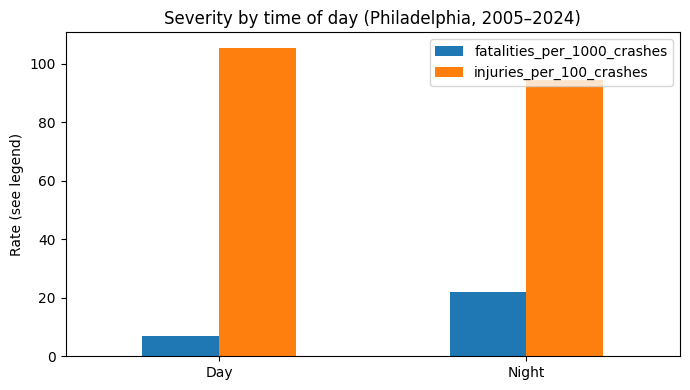

In [17]:
# Bar chart: fatalities per 1,000 crashes + injuries per 100 crashes

plot_df = night_day[['fatalities_per_1000_crashes', 'injuries_per_100_crashes']].copy()

ax = plot_df.plot(kind='bar', figsize=(7,4))
ax.set_title("Severity by time of day (Philadelphia, 2005–2024)")
ax.set_ylabel("Rate (see legend)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

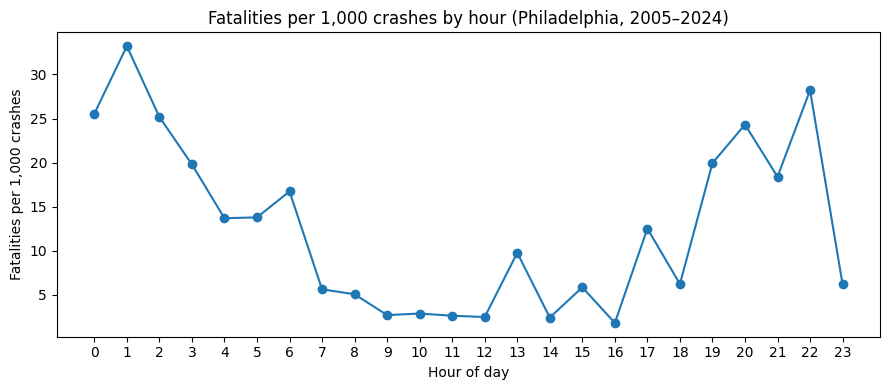

In [18]:
hour = (
    df.groupby('HOUR_OF_DAY')
      .agg(crashes=('CRN','count'),
           fatalities=('FATAL_COUNT','sum'),
           injuries=('TOT_INJ_COUNT','sum'))
)

hour['fatalities_per_1000_crashes'] = 1000 * hour['fatalities'] / hour['crashes']

plt.figure(figsize=(9,4))
plt.plot(hour.index, hour['fatalities_per_1000_crashes'], marker='o')
plt.title("Fatalities per 1,000 crashes by hour (Philadelphia, 2005–2024)")
plt.xlabel("Hour of day")
plt.ylabel("Fatalities per 1,000 crashes")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

In [19]:
# ---------------------------------------------
# Broad Street crash analysis (same method as Roosevelt)
# ---------------------------------------------

# 1) find Broad Street segments
broad = streets[
    (streets['st_name'].str.upper().eq('BROAD')) &
    (streets['st_type'].str.upper().eq('ST'))
].copy()

# 2) project to feet CRS for buffering
broad = broad.to_crs(epsg=2272)

# 3) create corridor buffer around Broad Street
buffer_ft = 100
broad_buf = gpd.GeoDataFrame(
    geometry=broad.buffer(buffer_ft),
    crs=broad.crs
)

# 4) restrict crashes to analysis period
city_11_15 = phil_crashes_gdf[
    (phil_crashes_gdf['CRASH_YEAR'] >= 2011) &
    (phil_crashes_gdf['CRASH_YEAR'] <= 2015)
].copy()

city_11_15 = city_11_15.to_crs(epsg=2272)

city_fatalities = city_11_15['FATAL_COUNT'].sum()

# 5) spatial join crashes within Broad Street corridor
joined = gpd.sjoin(city_11_15, broad_buf, predicate='within')
joined = joined.drop_duplicates(subset=['CRN'])

# 6) compute statistics
broad_fatalities = joined['FATAL_COUNT'].sum()
broad_share = broad_fatalities / city_fatalities

broad_injuries = joined['TOT_INJ_COUNT'].sum()
broad_ped_deaths = joined['PED_DEATH_COUNT'].sum()
broad_ped_share = broad_ped_deaths / broad_fatalities if broad_fatalities > 0 else float('nan')

print("\n--- Broad Street ---")
print("Crashes matched:", len(joined))
print("Fatalities:", int(broad_fatalities))
print("Share of city fatalities:", round(broad_share,4), f"({broad_share:.1%})")
print("Injuries:", int(broad_injuries))
print("Pedestrian deaths:", int(broad_ped_deaths))
print("Pedestrian share of deaths:", round(broad_ped_share,4), f"({broad_ped_share:.1%})")


--- Broad Street ---
Crashes matched: 2087
Fatalities: 24
Share of city fatalities: 0.0508 (5.1%)
Injuries: 2284
Pedestrian deaths: 13
Pedestrian share of deaths: 0.5417 (54.2%)


In [20]:
rb_length = rb_main.length.sum() / 5280
broad_length = broad.length.sum() / 5280

rb_rate = rb_fatalities / rb_length
broad_rate = broad_fatalities / broad_length

NameError: name 'rb_main' is not defined